In [2]:
import pandas as pd

In [3]:
df = pd.read_csv("car_data.csv")
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [6]:
df.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64

In [ ]:
df["Car_Name"].nunique() # so many unique cars

98

In [ ]:
df["Car_Name"].value_counts().head(10) #only top 10 unique car_names out of 98

Car_Name
city                         26
corolla altis                16
verna                        14
fortuner                     11
brio                         10
ciaz                          9
i20                           9
innova                        9
grand i10                     8
Royal Enfield Classic 350     7
Name: count, dtype: int64

In [ ]:
# dropping the car_name attribute
df = df.drop("Car_Name",axis=1)

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Year           301 non-null    int64  
 1   Selling_Price  301 non-null    float64
 2   Present_Price  301 non-null    float64
 3   Driven_kms     301 non-null    int64  
 4   Fuel_Type      301 non-null    object 
 5   Selling_type   301 non-null    object 
 6   Transmission   301 non-null    object 
 7   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(3)
memory usage: 18.9+ KB


In [16]:
# finding correlation between columns
df.corr(numeric_only=True)

,Year,Selling_Price,Present_Price,Driven_kms,Owner
Year,1.000000,0.236141,-0.047192,-0.524342,-0.182104
Selling_Price,0.236141,1.000000,0.878914,0.029187,-0.088344
Present_Price,-0.047192,0.878914,1.000000,0.203618,0.008058
Driven_kms,-0.524342,0.029187,0.203618,1.000000,0.089216
Owner,-0.182104,-0.088344,0.008058,0.089216,1.000000


In [17]:
corr_matrix = df.corr(numeric_only=True)

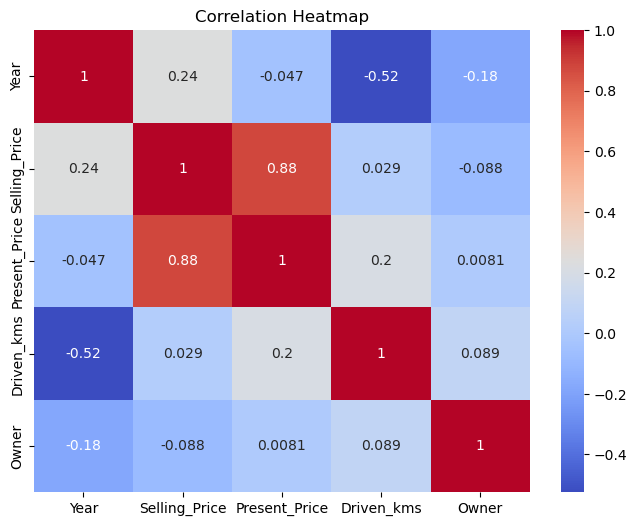

In [23]:
# creating the heatmap for better visualization
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [ ]:

df["Transmission"].value_counts()

Transmission
Manual       261
Automatic     40
Name: count, dtype: int64

In [25]:
df["Fuel_Type"].value_counts()



Fuel_Type
Petrol    239
Diesel     60
CNG         2
Name: count, dtype: int64

In [26]:
df["Selling_type"].value_counts()


Selling_type
Dealer        195
Individual    106
Name: count, dtype: int64

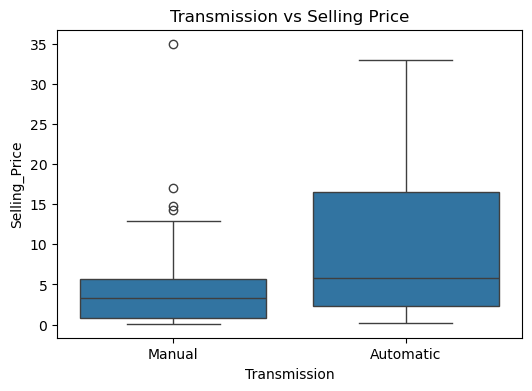

In [ ]:
# boxplot for transmission and selling price
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.boxplot(x='Transmission', y='Selling_Price', data=df)

plt.title("Transmission vs Selling Price")
plt.show()

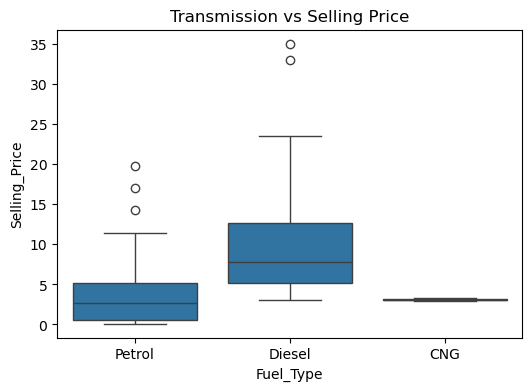

In [ ]:
# boxplot for fuel type and selling price
plt.figure(figsize=(6,4))
sns.boxplot(x='Fuel_Type', y='Selling_Price', data=df)

plt.title("Fuel Type vs Selling Price")
plt.show()

In [32]:
df.head()

,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [34]:
df['Transmission'] = df['Transmission'].map({
    'Manual':0,
    'Automatic':1
})

In [36]:
df['Selling_type'] = df['Selling_type'].map({
    'Dealer':0,
    'Individual':1
})

In [37]:
df.head()

,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,2014,3.35,5.59,27000,Petrol,0,0,0
1,2013,4.75,9.54,43000,Diesel,0,0,0
2,2017,7.25,9.85,6900,Petrol,0,0,0
3,2011,2.85,4.15,5200,Petrol,0,0,0
4,2014,4.60,6.87,42450,Diesel,0,0,0


In [43]:
df = pd.get_dummies(df, columns=['Fuel_Type'], drop_first=True)

In [44]:
X = df.drop('Selling_Price', axis=1)

y = df['Selling_Price']

In [45]:
# Train test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [ ]:
# first model -> Linear Regression model
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [47]:
y_pred = model.predict(X_test)

In [48]:
# R2 score
from sklearn.metrics import r2_score
print(r2_score(y_test, y_pred))

0.8488707839192589


In [49]:
# Second model -> Random Forest Regressor

from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)


,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [50]:
rf_pred = rf.predict(X_test)

In [52]:
rf_score = r2_score(y_test, rf_pred)
print(rf_score)

0.9646002256687567


In [55]:
# Feature Importance

import pandas as pd

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance', ascending=False
)

print(importance)

            Feature  Importance
1     Present_Price    0.883414
0              Year    0.061994
2        Driven_kms    0.035632
4      Transmission    0.008126
7  Fuel_Type_Petrol    0.004020
3      Selling_type    0.002975
6  Fuel_Type_Diesel    0.002653
5             Owner    0.001185


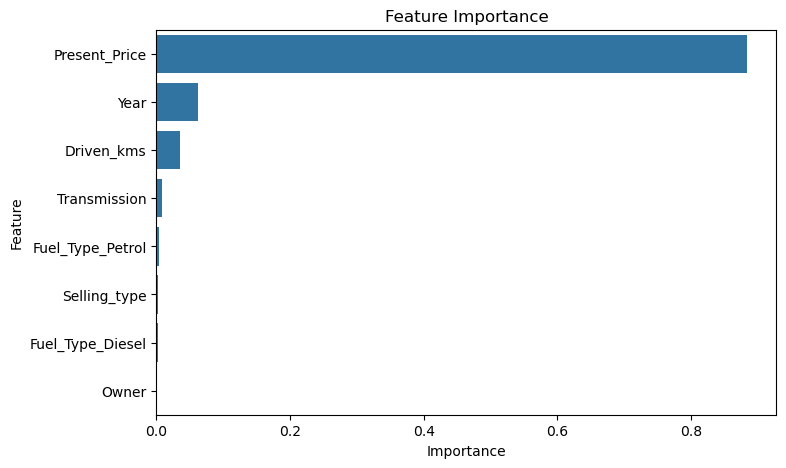

In [57]:
# Feature Importance Graph
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.barplot(
    x='Importance',
    y='Feature',
    data= importance
)

plt.title("Feature Importance")
plt.show()

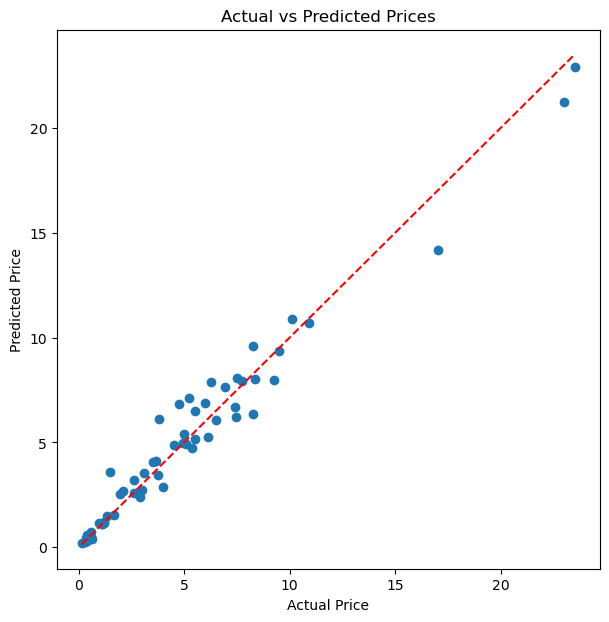

In [58]:
plt.figure(figsize=(7,7))

plt.scatter(y_test, rf_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted Prices")

plt.show()